In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create simulated stock price time-series data
np.random.seed(42)
n_days = 500
dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

# Simulate stock price with trend + noise
trend = np.linspace(100, 180, n_days)
noise = np.random.normal(0, 5, n_days)
seasonal = 10 * np.sin(np.linspace(0, 20*np.pi, n_days))
price = trend + noise + seasonal

df = pd.DataFrame({'Date': dates, 'Close': price})
df['Day_Number'] = range(len(df))

print("✅ Stock Dataset Created!")
print("Shape:", df.shape)
df.head()

✅ Stock Dataset Created!
Shape: (500, 3)


,Date,Close,Day_Number
0,2023-01-01,102.483571,0
1,2023-01-02,100.724830,1
2,2023-01-03,106.050861,2
3,2023-01-04,111.784380,3
4,2023-01-05,104.296877,4


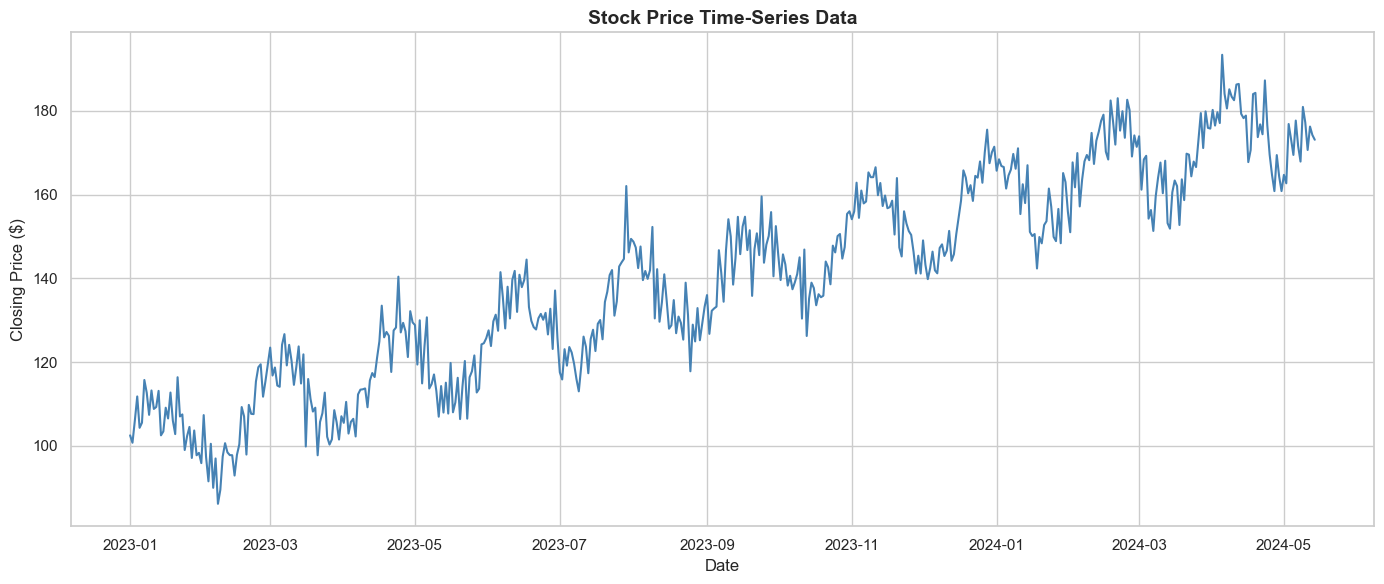

✅ Time-Series Visualized!


In [4]:
plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='steelblue', linewidth=1.5)
plt.title('Stock Price Time-Series Data', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price ($)', fontsize=12)
plt.tight_layout()
plt.show()
print("✅ Time-Series Visualized!")

In [5]:
# Split 80% past data for training, 20% recent data for testing
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df  = df.iloc[split_idx:]

X_train = train_df[['Day_Number']]
y_train = train_df['Close']
X_test  = test_df[['Day_Number']]
y_test  = test_df['Close']

print("✅ Chronological Split Done!")
print(f"Training samples : {len(X_train)} (oldest data)")
print(f"Testing  samples : {len(X_test)} (most recent data)")
print("\n⚠️ Note: We split by TIME, NOT randomly,")
print("   because future cannot be used to predict the past!")

✅ Chronological Split Done!
Training samples : 400 (oldest data)
Testing  samples : 100 (most recent data)

⚠️ Note: We split by TIME, NOT randomly,
   because future cannot be used to predict the past!


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Linear Regression Model Trained!")
print(f"Slope (trend per day) : {model.coef_[0]:.4f}")
print(f"Intercept             : {model.intercept_:.2f}")

✅ Linear Regression Model Trained!
Slope (trend per day) : 0.1574
Intercept             : 100.70


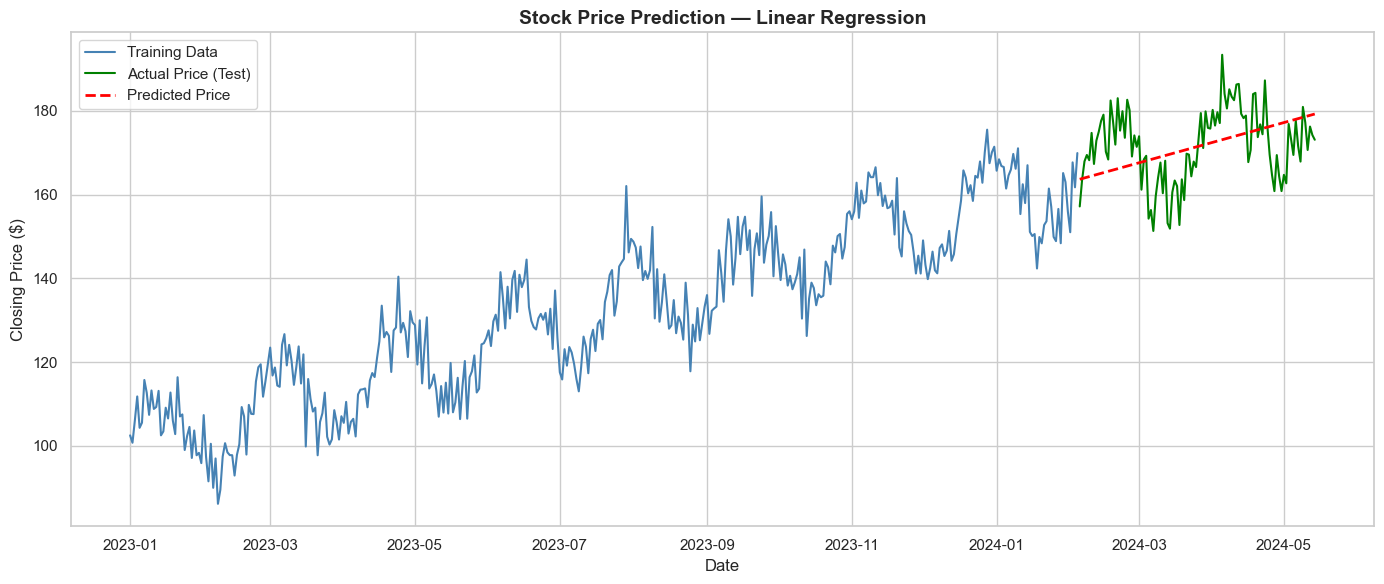

✅ Predictions Visualized!


In [7]:
y_pred = model.predict(X_test)

plt.figure(figsize=(14, 6))
plt.plot(train_df['Date'], y_train, color='steelblue', label='Training Data')
plt.plot(test_df['Date'], y_test, color='green', label='Actual Price (Test)')
plt.plot(test_df['Date'], y_pred, color='red', linestyle='--',
         linewidth=2, label='Predicted Price')
plt.title('Stock Price Prediction — Linear Regression',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Predictions Visualized!")

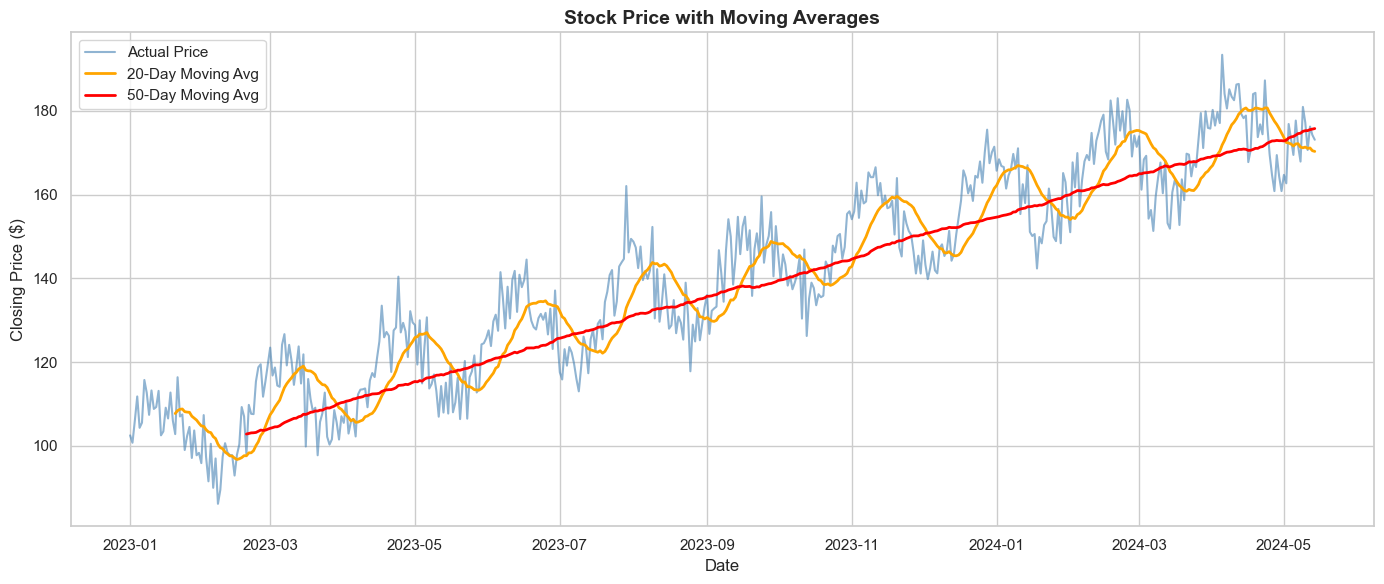

✅ Moving Averages Plotted!


In [8]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 6))
plt.plot(df['Date'], df['Close'], color='steelblue', alpha=0.6, label='Actual Price')
plt.plot(df['Date'], df['MA_20'], color='orange', linewidth=2, label='20-Day Moving Avg')
plt.plot(df['Date'], df['MA_50'], color='red', linewidth=2, label='50-Day Moving Avg')
plt.title('Stock Price with Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend()
plt.tight_layout()
plt.show()
print("✅ Moving Averages Plotted!")

In [9]:
mse = mean_squared_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("=" * 45)
print("      MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"✅ MSE       : {mse:.2f}")
print(f"✅ RMSE      : {np.sqrt(mse):.2f}")
print(f"✅ R-squared : {r2:.4f} ({r2*100:.1f}%)")
print("=" * 45)

      MODEL EVALUATION RESULTS
✅ MSE       : 81.07
✅ RMSE      : 9.00
✅ R-squared : -0.0667 (-6.7%)


In [10]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_days = 500
dates = pd.date_range(start='2023-01-01', periods=n_days, freq='D')

trend = np.linspace(100, 180, n_days)
noise = np.random.normal(0, 5, n_days)
seasonal = 10 * np.sin(np.linspace(0, 20*np.pi, n_days))
price = trend + noise + seasonal

df = pd.DataFrame({'Date': dates, 'Close': price})
df['Day_Number'] = range(len(df))

# Save as CSV
df.to_csv('stock_price_data.csv', index=False)

print("✅ CSV file saved successfully!")
print("Location:", __import__('os').getcwd())
print("Shape:", df.shape)
df.head()

✅ CSV file saved successfully!
Location: C:\Users\Disha\Videos
Shape: (500, 3)


,Date,Close,Day_Number
0,2023-01-01,102.483571,0
1,2023-01-02,100.724830,1
2,2023-01-03,106.050861,2
3,2023-01-04,111.784380,3
4,2023-01-05,104.296877,4



INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. What is Seasonality in Time Series?
    Seasonality = Repeating PATTERN at fixed time intervals
    Example: Ice cream sales rise every summer, every year
    It repeats regularly (daily, weekly, monthly, yearly)
    Different from trend, which is long-term direction.

Q2. Can Linear Regression Perfectly Predict Stock Prices?
    NO. Linear Regression assumes a straight-line trend,
    but stock prices are affected by:
    - Random market news and events
    - Investor emotions and sentiment
    - Sudden economic changes
    Stock prices are highly volatile and NON-LINEAR,
    so Linear Regression only gives a rough estimate,
    not perfect predictions.

══════════════════════════════════════════════════════
